In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay
)
from scipy.stats import randint
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
df = pd.read_csv("Cancer_Data.csv")

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['diagnosis'].value_counts()}")

Shape: (569, 32)

Class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [6]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [7]:
df.drop(columns=['id'], inplace=True)

In [8]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [9]:
missing = df.isna().sum().sum()
print(f"\nMissing values: {missing}")
print(f"Final shape: {df.shape}")


Missing values: 0
Final shape: (569, 31)


In [10]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)} ")


Train: 455  |  Test: 114 


In [11]:
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)
 
y_pred_train = dt.predict(X_train)
y_pred_test  = dt.predict(X_test)
 
train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)
 
print("\n--- Decision Tree (baseline) ---")
print(f"Training Accuracy : {train_acc:.4f}")
print(f"Test Accuracy     : {test_acc:.4f}")
print(f"Overfitting Gap   : {train_acc - test_acc:.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=['Benign', 'Malignant']))


--- Decision Tree (baseline) ---
Training Accuracy : 1.0000
Test Accuracy     : 0.9561
Overfitting Gap   : 0.0439

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



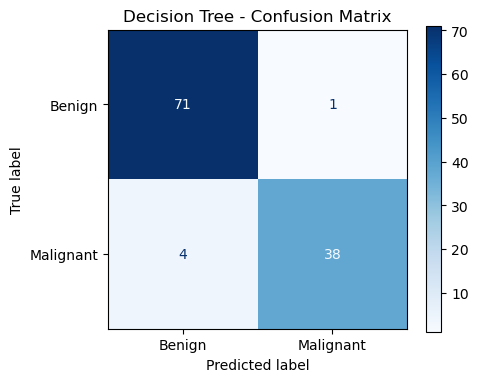

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['Benign', 'Malignant'],
    cmap='Blues', ax=ax
)
ax.set_title('Decision Tree - Confusion Matrix')
plt.tight_layout()
plt.show()

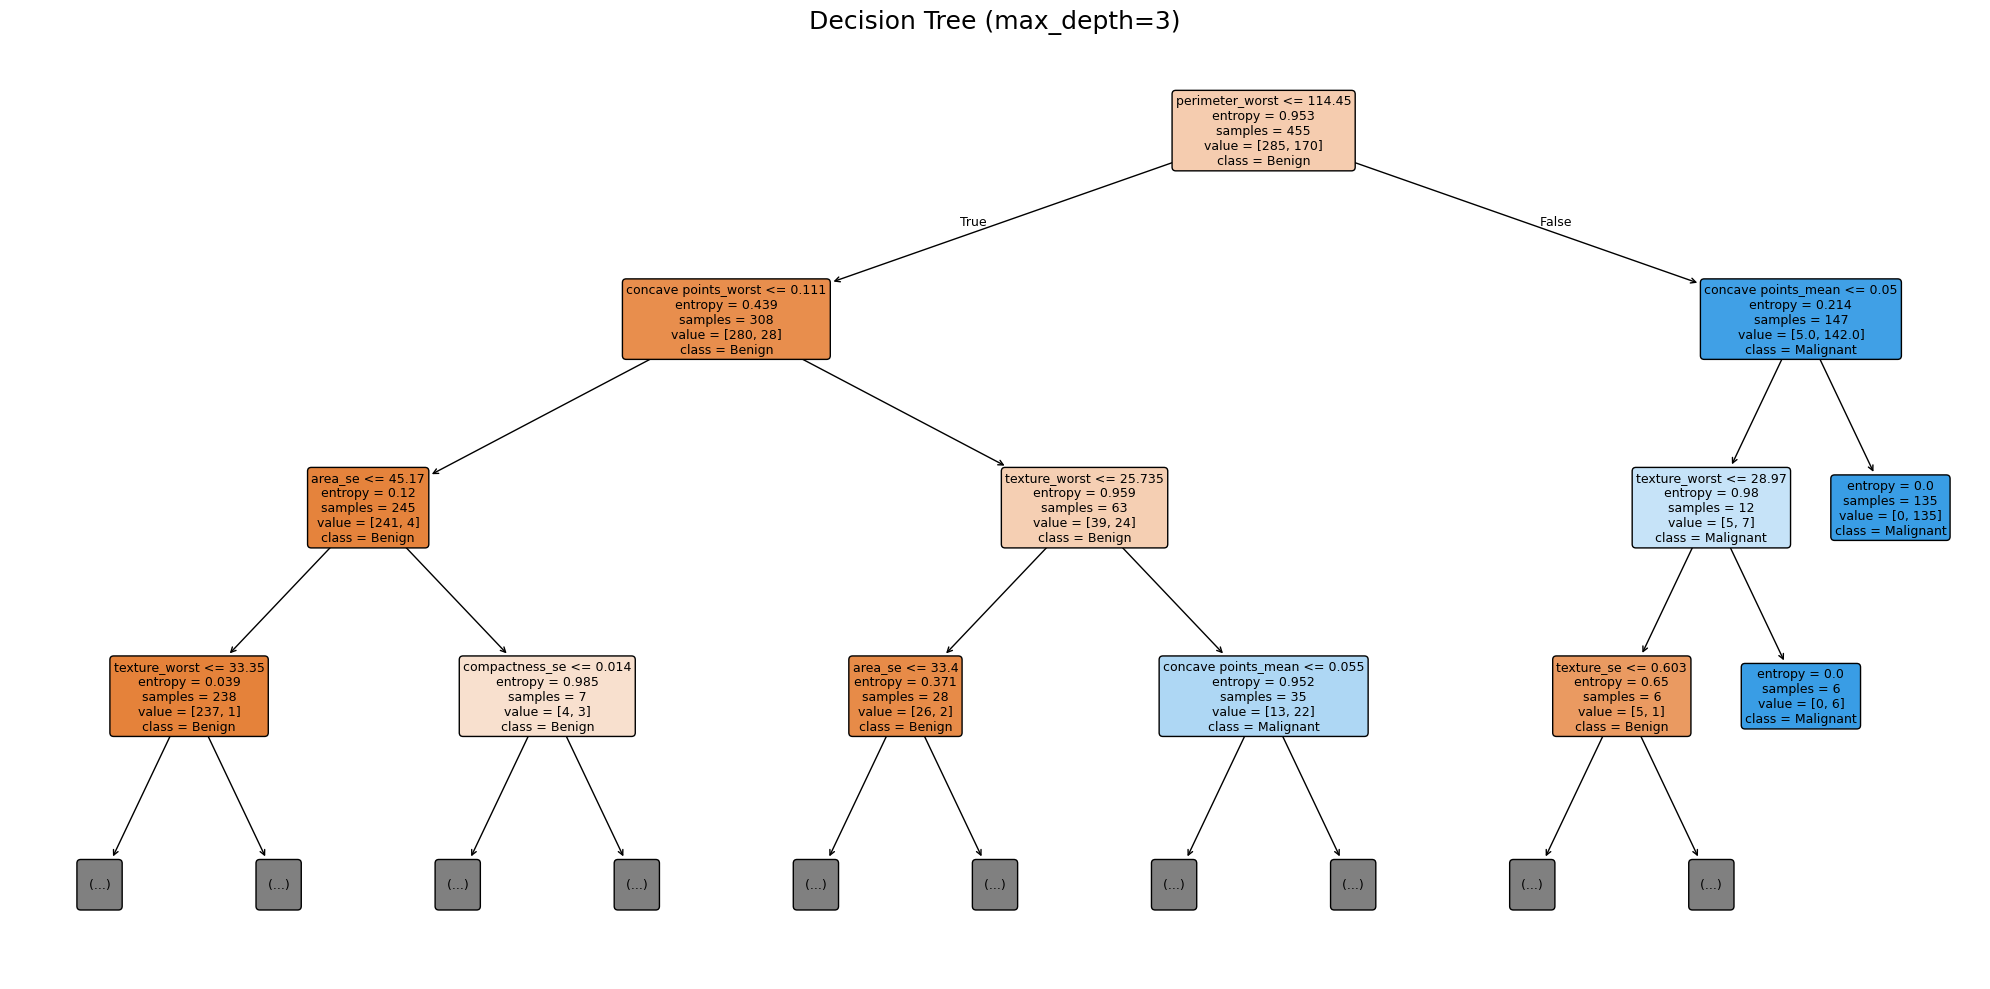

In [13]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=['Benign', 'Malignant'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree (max_depth=3)", fontsize=18)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=200, bbox_inches='tight')
plt.show()

In [14]:
def entropy(y):
    """Binary entropy in bits."""
    y = np.asarray(y)
    counts = np.bincount(y)
    probs  = counts[counts > 0] / len(y)
    return -np.sum(probs * np.log2(probs))
 
feature   = 'radius_mean'
threshold = X_train[feature].median()
 
left_mask  = X_train[feature] <= threshold
right_mask = X_train[feature] >  threshold
y_left     = y_train[left_mask]
y_right    = y_train[right_mask]
 
H_total    = entropy(y_train)
H_left     = entropy(y_left)
H_right    = entropy(y_right)
H_weighted = (len(y_left)/len(y_train))*H_left + (len(y_right)/len(y_train))*H_right
IG         = H_total - H_weighted
 
print(f"\n--- Information Gain on '{feature}' ---")
print(f"Total entropy   : {H_total:.4f} bits")
print(f"Left  ({len(y_left):3d})      : H = {H_left:.4f}")
print(f"Right ({len(y_right):3d})     : H = {H_right:.4f}")
print(f"Weighted entropy: {H_weighted:.4f}")
print(f"Information Gain: {IG:.4f}")


--- Information Gain on 'radius_mean' ---
Total entropy   : 0.9534 bits
Left  (228)      : H = 0.3500
Right (227)     : H = 0.9013
Weighted entropy: 0.6250
Information Gain: 0.3284


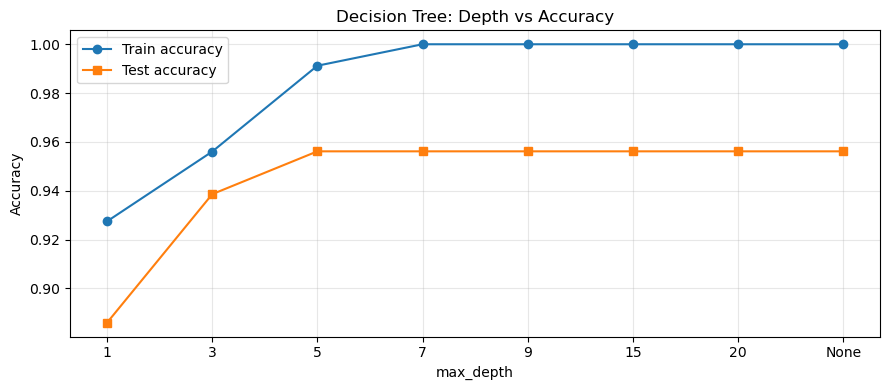


Depth       Train     Test      Gap
------------------------------------
1          0.9275   0.8860   0.0415
3          0.9560   0.9386   0.0174
5          0.9912   0.9561   0.0351
7          1.0000   0.9561   0.0439
9          1.0000   0.9561   0.0439
15         1.0000   0.9561   0.0439
20         1.0000   0.9561   0.0439
None       1.0000   0.9561   0.0439


In [15]:
depths       = [1, 3, 5, 7, 9, 15, 20, None]
train_scores = []
test_scores  = []
 
for depth in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  clf.predict(X_test)))
 
depth_labels = [str(d) if d is not None else 'None' for d in depths]
 
plt.figure(figsize=(9, 4))
plt.plot(depth_labels, train_scores, 'o-', label='Train accuracy')
plt.plot(depth_labels, test_scores,  's-', label='Test accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Depth vs Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
print(f"\n{'Depth':<8} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("-" * 36)
for d, tr, te in zip(depth_labels, train_scores, test_scores):
    print(f"{d:<8} {tr:>8.4f} {te:>8.4f} {tr-te:>8.4f}")

In [16]:
param_grid = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8],
    'criterion'        : ['gini', 'entropy']
}
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)
 
print("\n--- Grid Search ---")
print(f"Best params : {grid_search.best_params_}")
print(f"CV score    : {grid_search.best_score_:.4f}")
print(f"Test score  : {grid_search.score(X_test, y_test):.4f}")


--- Grid Search ---
Best params : {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}
CV score    : 0.9473
Test score  : 0.9561


In [17]:
param_dist = {
    'max_depth'        : randint(3, 20),
    'min_samples_split': randint(2, 30),
    'min_samples_leaf' : randint(1, 15),
    'criterion'        : ['gini', 'entropy']
}
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dist, n_iter=100, cv=5,
    scoring='accuracy', random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train)
 
print("\n--- Randomized Search ---")
print(f"Best params : {random_search.best_params_}")
print(f"CV score    : {random_search.best_score_:.4f}")
print(f"Test score  : {random_search.score(X_test, y_test):.4f}")


--- Randomized Search ---
Best params : {'criterion': 'entropy', 'max_depth': 11, 'min_samples_leaf': 12, 'min_samples_split': 8}
CV score    : 0.9429
Test score  : 0.9386


In [18]:
def objective(trial):
    params = {
        'criterion'        : trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'max_depth'        : trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 25),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10)
    }
    clf = DecisionTreeClassifier(**params, random_state=42)
    return cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy').mean()
 
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
 
best_dt = DecisionTreeClassifier(**study.best_params, random_state=42)
best_dt.fit(X_train, y_train)
 
print("\n--- Optuna ---")
print(f"Best params : {study.best_params}")
print(f"CV score    : {study.best_value:.4f}")
print(f"Test score  : {best_dt.score(X_test, y_test):.4f}")


--- Optuna ---
Best params : {'criterion': 'entropy', 'max_depth': 14, 'min_samples_split': 16, 'min_samples_leaf': 7}
CV score    : 0.9429
Test score  : 0.9737


In [19]:
print(f"\n{'Method':<20} {'CV Score':>10} {'Test Score':>12}")
print("-" * 44)
for name, cv, ts in [
    ('Grid Search',    grid_search.best_score_,  grid_search.score(X_test, y_test)),
    ('Random Search',  random_search.best_score_, random_search.score(X_test, y_test)),
    ('Optuna',         study.best_value,           best_dt.score(X_test, y_test)),
]:
    print(f"{name:<20} {cv:>10.4f} {ts:>12.4f}")


Method                 CV Score   Test Score
--------------------------------------------
Grid Search              0.9473       0.9561
Random Search            0.9429       0.9386
Optuna                   0.9429       0.9737


In [20]:
rf = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)
rf.fit(X_train, y_train)
 
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf  = rf.predict(X_test)
 
train_acc_rf = accuracy_score(y_train, y_pred_train_rf)
test_acc_rf  = accuracy_score(y_test,  y_pred_test_rf)
 
print("\n--- Random Forest ---")
print(f"Training Accuracy : {train_acc_rf:.4f}")
print(f"Test Accuracy     : {test_acc_rf:.4f}")
print(f"OOB Score         : {rf.oob_score_:.4f}")
print(f"Overfitting Gap   : {train_acc_rf - test_acc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_test_rf, target_names=['Benign', 'Malignant']))


--- Random Forest ---
Training Accuracy : 1.0000
Test Accuracy     : 0.9737
OOB Score         : 0.9538
Overfitting Gap   : 0.0263

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



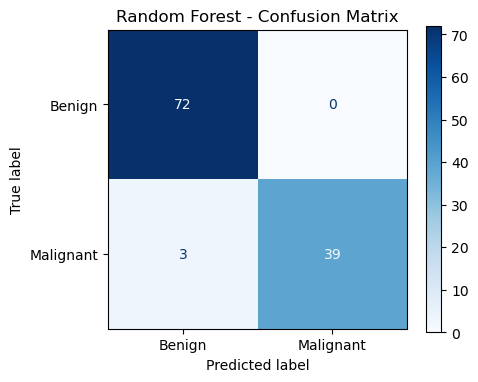

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test_rf,
    display_labels=['Benign', 'Malignant'],
    cmap='Blues', ax=ax
)
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

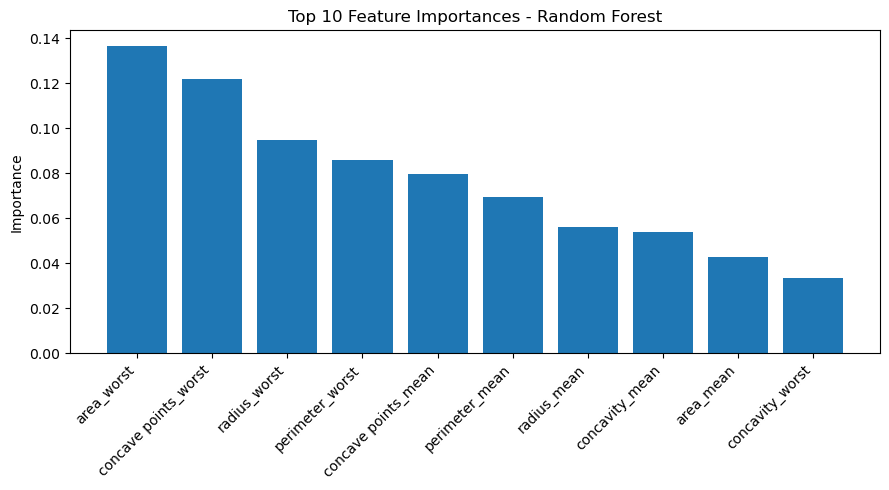


Rank  Feature                     Importance
--------------------------------------------
1     area_worst                      0.1367
2     concave points_worst            0.1219
3     radius_worst                    0.0946
4     perimeter_worst                 0.0859
5     concave points_mean             0.0796
6     perimeter_mean                  0.0695
7     radius_mean                     0.0561
8     concavity_mean                  0.0540
9     area_mean                       0.0429
10    concavity_worst                 0.0333


In [24]:
importances   = rf.feature_importances_
feature_names = X_train.columns
top_n         = 10
indices       = np.argsort(importances)[::-1][:top_n]
 
plt.figure(figsize=(9, 5))
plt.bar(range(top_n), importances[indices])
plt.xticks(range(top_n), feature_names[indices], rotation=45, ha='right')
plt.ylabel('Importance')
plt.title(f'Top {top_n} Feature Importances - Random Forest')
plt.tight_layout()
plt.show()
 
print(f"\n{'Rank':<5} {'Feature':<25} {'Importance':>12}")
print("-" * 44)
for rank, idx in enumerate(indices, 1):
    print(f"{rank:<5} {feature_names[idx]:<25} {importances[idx]:>12.4f}")
 

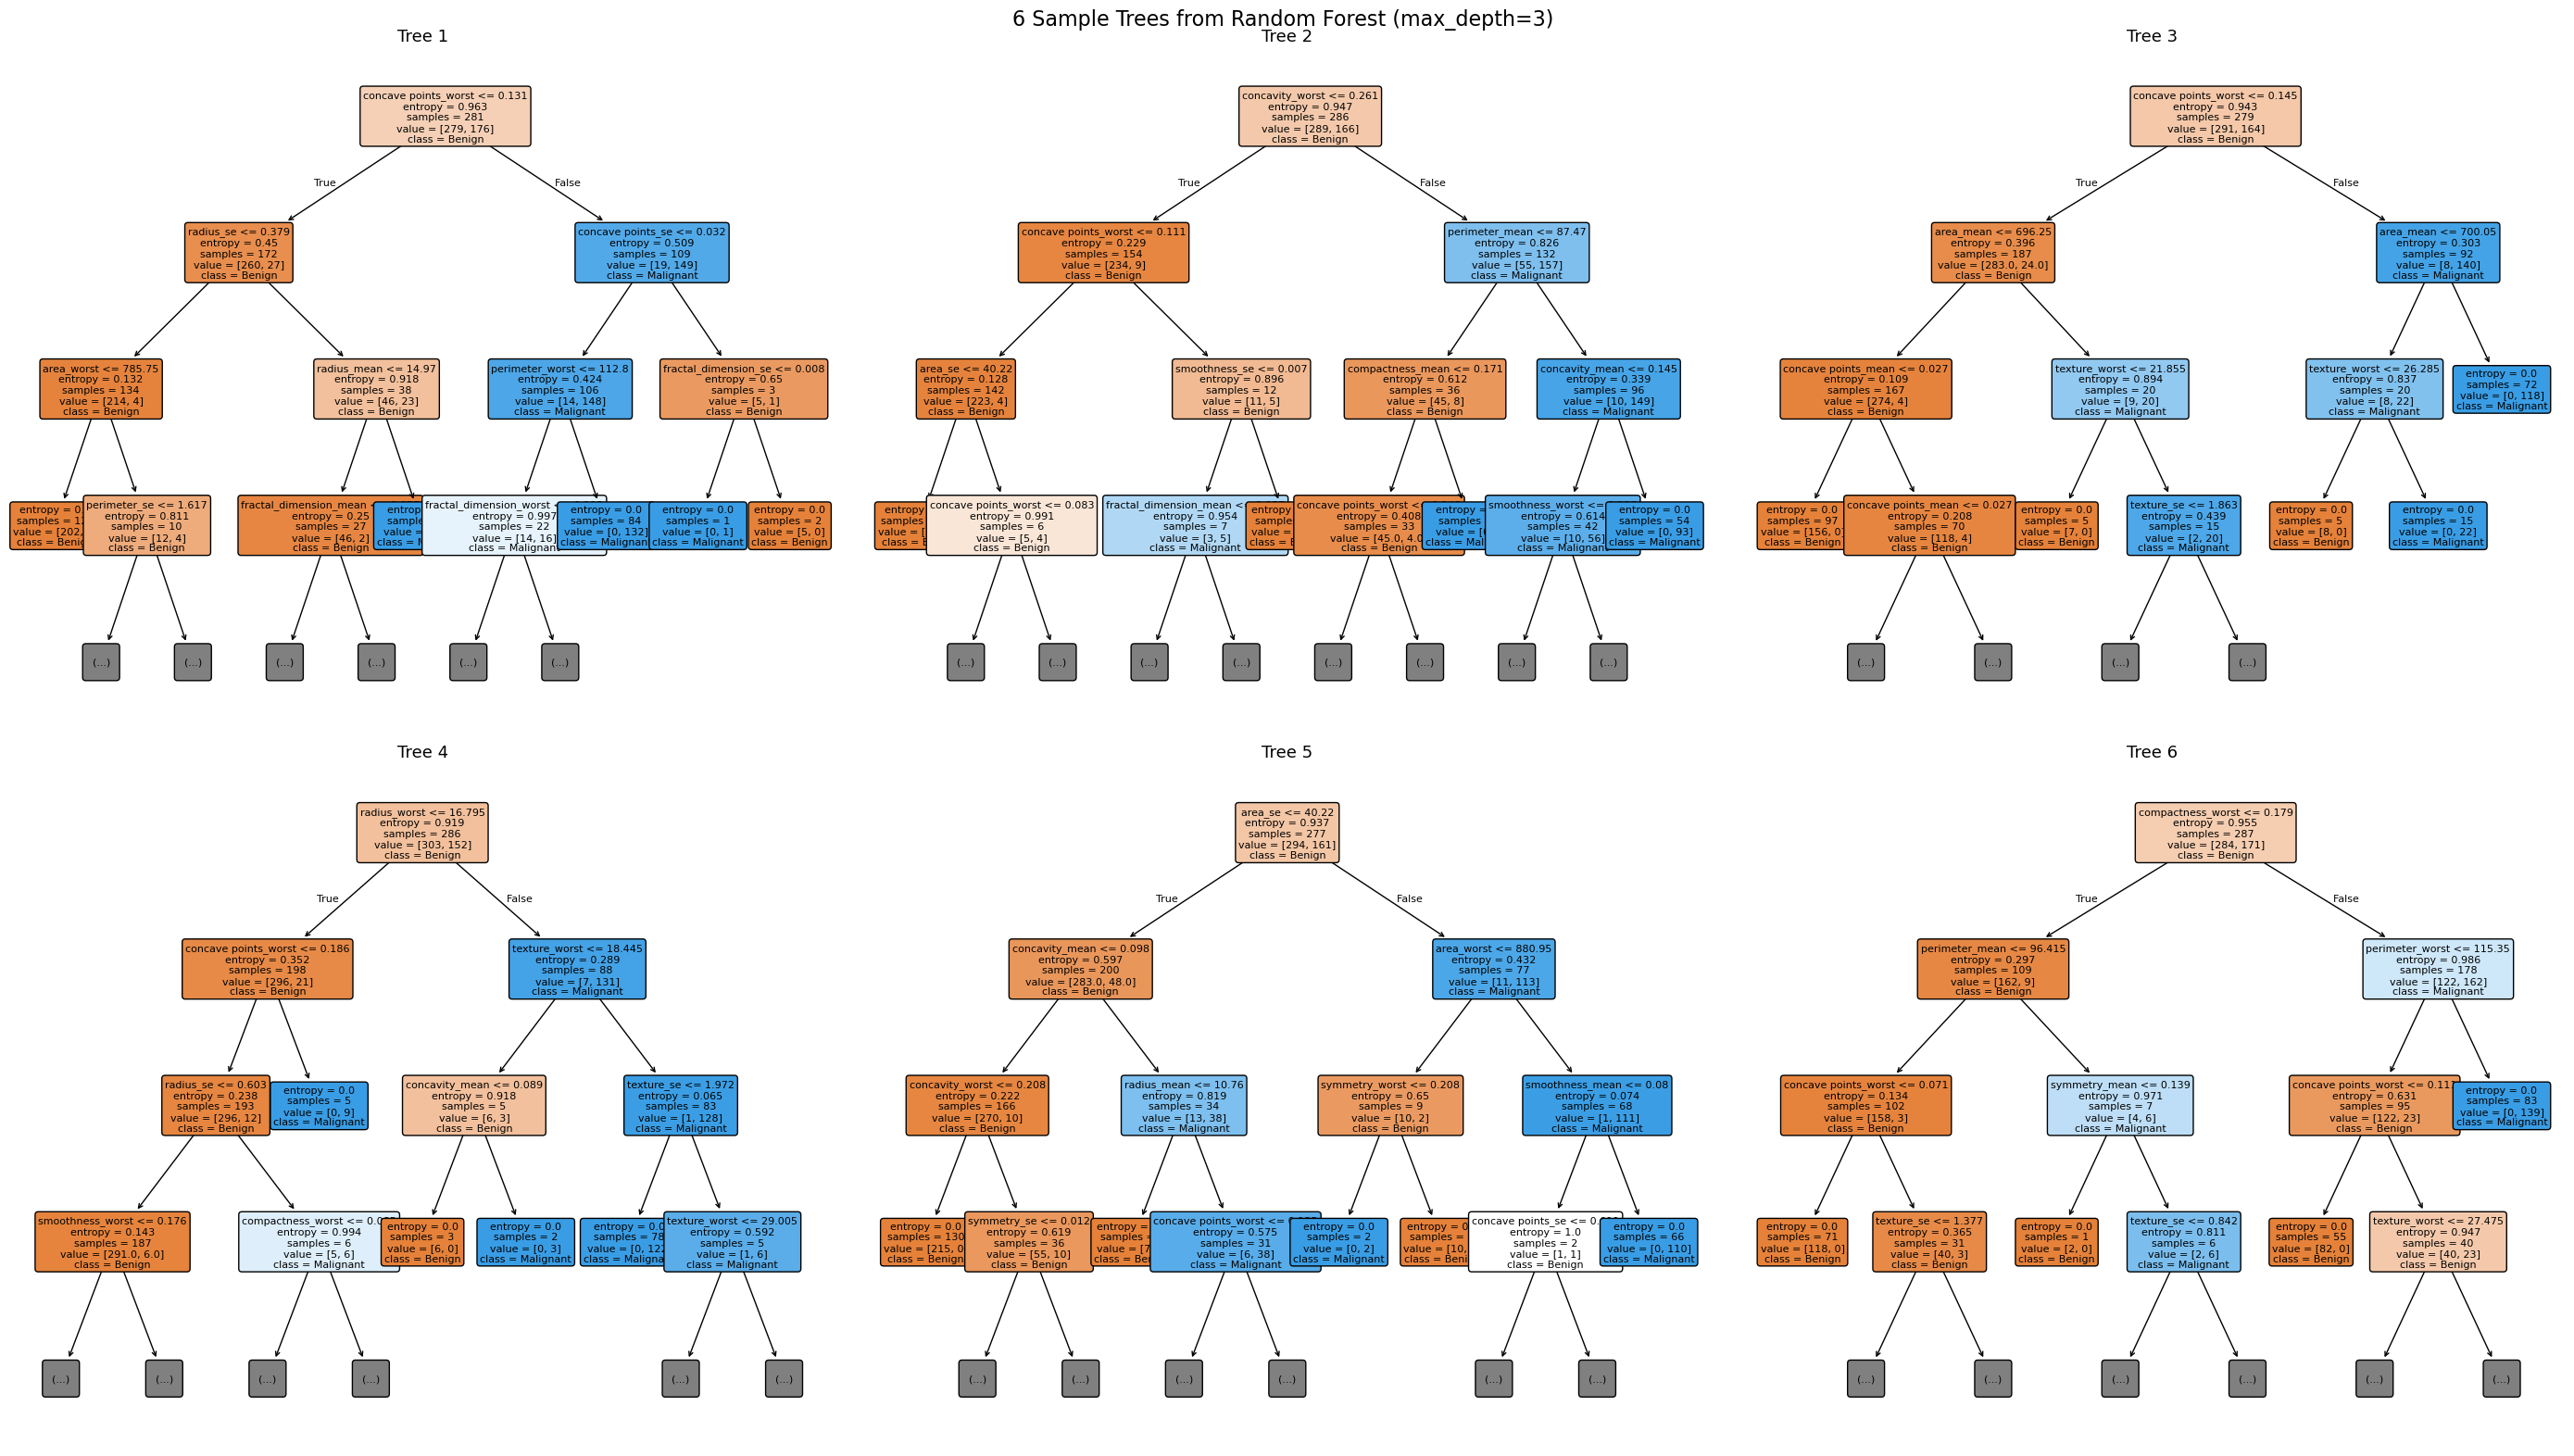

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(28, 16))
for idx, ax in enumerate(axes.flatten()):
    plot_tree(
        rf.estimators_[idx],
        max_depth=3,
        feature_names=X_train.columns,
        class_names=['Benign', 'Malignant'],
        filled=True, rounded=True,
        ax=ax, fontsize=8
    )
    ax.set_title(f'Tree {idx + 1}', fontsize=13)
plt.suptitle('6 Sample Trees from Random Forest (max_depth=3)', fontsize=16)
plt.tight_layout()
plt.show()

In [26]:
results = {
    'Decision Tree (baseline)'     : test_acc,
    'Decision Tree (Grid Search)'  : grid_search.score(X_test, y_test),
    'Decision Tree (Random Search)': random_search.score(X_test, y_test),
    'Decision Tree (Optuna)'       : best_dt.score(X_test, y_test),
    'Random Forest'                : test_acc_rf,
}
 
print(f"\n{'Model':<35} {'Test Accuracy':>14}")
print("-" * 52)
best_score = max(results.values())
for model, acc in results.items():
    marker = " ← best" if acc == best_score else ""
    print(f"{model:<35} {acc:>14.4f}{marker}")
 
print(f"\nRandom Forest improvement over baseline DT: "
      f"{(test_acc_rf - test_acc)*100:+.2f}%")


Model                                Test Accuracy
----------------------------------------------------
Decision Tree (baseline)                    0.9561
Decision Tree (Grid Search)                 0.9561
Decision Tree (Random Search)               0.9386
Decision Tree (Optuna)                      0.9737 ← best
Random Forest                               0.9737 ← best

Random Forest improvement over baseline DT: +1.75%
